# real ppg -> dbp: probe then patch

PyTorch transformer (4 heads, 3 layers, default dropout) on real VitalDB ECG+PPG, regressing DBP.
Same read-probe / write-patch methodology as `ppg_mech_interp_tutorial.ipynb`: train -> save/load ->
pull per-layer activations -> linear-probe them for PAT / cardiac timing -> activation-patch to check
whether the model actually *uses* what's decodable.

device=mps  fs=125Hz  window=10.0s
Xtr (4000, 1250, 2) Xva (1200, 1250, 2) Xte (1200, 1250, 2)  -- (segments, timesteps, [ecg, ppg])


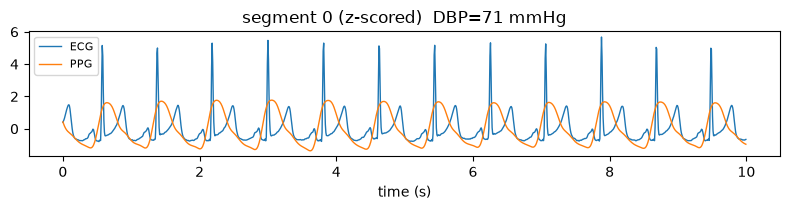

In [1]:
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import mechlib

torch.manual_seed(0); np.random.seed(0)
dev = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
ECG, PPG = 0, 1

d = mechlib.load_mini("../data/vitaldb_mini.npz"); fs = int(d["fs"])
Xtr = mechlib.normalize(d["Xtr"][:, :, [ECG, PPG]]); ytr = d["ytr"][:, 1]   # DBP only
Xva = mechlib.normalize(d["Xva"][:, :, [ECG, PPG]]); yva = d["yva"][:, 1]
Xte = mechlib.normalize(d["Xte"][:, :, [ECG, PPG]]); yte = d["yte"][:, 1]

print(f"device={dev}  fs={fs}Hz  window={Xtr.shape[1]/fs:.1f}s")
print("Xtr", Xtr.shape, "Xva", Xva.shape, "Xte", Xte.shape, " -- (segments, timesteps, [ecg, ppg])")

t_axis = np.arange(Xtr.shape[1]) / fs
plt.figure(figsize=(8, 2.2))
plt.plot(t_axis, Xtr[0, :, ECG], lw=1, label="ECG"); plt.plot(t_axis, Xtr[0, :, PPG], lw=1, label="PPG")
plt.title(f"segment 0 (z-scored)  DBP={ytr[0]:.0f} mmHg"); plt.xlabel("time (s)")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## model: 3-layer transformer, 4 heads, default dropout

In [2]:
DM, PATCH, HEADS, DEPTH = 64, 25, 4, 3          # default dropout (0.1), same as mechlib.WaveTransformer

net = mechlib.WaveTransformer(n_ch=2, dm=DM, patch=PATCH, heads=HEADS, depth=DEPTH, L=Xtr.shape[1]).to(dev)
print(net)

WaveTransformer(
  (embed): Conv1d(2, 64, kernel_size=(25,), stride=(25,))
  (tr): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Linear(in_features=64, out_features=1, bias=True)
)


## train, watch it converge

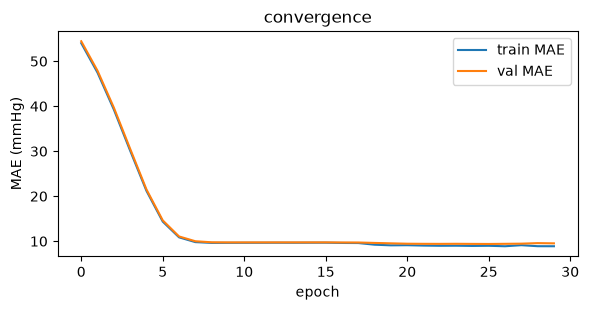

test DBP MAE: 9.20 mmHg   (predict-the-mean baseline: 9.45)


In [3]:
def train(net, epochs=30, bs=128, lr=2e-3):
    opt = torch.optim.Adam(net.parameters(), lr)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)
    Xt, yt = torch.tensor(Xtr, device=dev), torch.tensor(ytr, device=dev)
    Xv, yv = torch.tensor(Xva, device=dev), torch.tensor(yva, device=dev)
    hist = {"train_mae": [], "val_mae": []}
    best_val, best_state = float("inf"), None
    for ep in range(epochs):
        net.train(); perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), bs):
            b = perm[i:i + bs]
            loss = ((net(Xt[b]) - yt[b]) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step(); net.eval()
        with torch.no_grad():
            tm = float((net(Xt) - yt).abs().mean())
            vm = float((net(Xv) - yv).abs().mean())
        hist["train_mae"].append(tm); hist["val_mae"].append(vm)
        if vm < best_val:
            best_val, best_state = vm, {k: v.clone() for k, v in net.state_dict().items()}
    net.load_state_dict(best_state); net.eval()
    return hist

hist = train(net)

plt.figure(figsize=(6, 3.2))
plt.plot(hist["train_mae"], label="train MAE")
plt.plot(hist["val_mae"], label="val MAE")
plt.xlabel("epoch"); plt.ylabel("MAE (mmHg)"); plt.title("convergence"); plt.legend()
plt.tight_layout(); plt.show()

base = np.abs(ytr.mean() - yte).mean()
with torch.no_grad():
    mae = float((net(torch.tensor(Xte, device=dev)).cpu() - torch.tensor(yte)).abs().mean())
print(f"test DBP MAE: {mae:.2f} mmHg   (predict-the-mean baseline: {base:.2f})")

## save / load

In [4]:
ckpt_path = "../data/dbp_transformer.pt"
torch.save({"state_dict": net.state_dict(), "history": hist, "config": net.cfg}, ckpt_path)

ckpt = torch.load(ckpt_path, map_location=dev)
net2 = mechlib.WaveTransformer(**ckpt["config"]).to(dev)
net2.load_state_dict(ckpt["state_dict"])
net2.eval()

with torch.no_grad():
    xb = torch.tensor(Xte[:64], device=dev)
    same = torch.allclose(net(xb), net2(xb))
print(f"saved -> {ckpt_path}  (state_dict + history + config)")
print(f"reloaded from config {ckpt['config']}, predictions match: {same}")
net = net2   # continue with the reloaded copy

saved -> ../data/dbp_transformer.pt  (state_dict + history + config)
reloaded from config {'n_ch': 2, 'dm': 64, 'patch': 25, 'heads': 4, 'depth': 3, 'L': 1250}, predictions match: True


## pull activations per layer, linear-probe for PAT / cardiac timing

         layer |  pat R2 |  period R2
   patch embed |   -0.06 |      -0.03
       layer 1 |    0.24 |       0.49
       layer 2 |    0.16 |       0.39
       layer 3 |    0.16 |       0.37


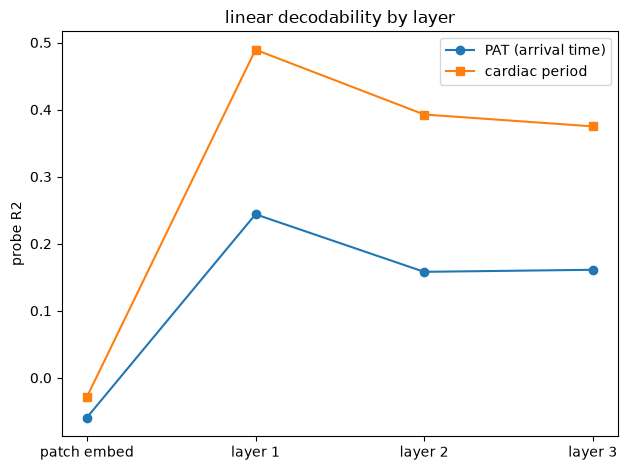

In [5]:
@torch.no_grad()
def layer_features(net, X, bs=512):
    outs = None
    for s in range(0, len(X), bs):
        x = torch.tensor(X[s:s + bs], device=dev)
        _, acts = net(x, return_acts=True)
        pooled = [a.mean(1).cpu().numpy() for a in acts]     # mean-pool tokens -> (n, DM) per layer
        outs = pooled if outs is None else [np.concatenate([o, p]) for o, p in zip(outs, pooled)]
    names = ["patch embed"] + [f"layer {i + 1}" for i in range(DEPTH)]
    return dict(zip(names, outs))

scalars = mechlib.compute_scalars(Xte, fs, ECG, PPG)
stages = layer_features(net, Xte)

r2 = {name: (mechlib.linear_probe(f, scalars["pat"]), mechlib.linear_probe(f, scalars["period"]))
      for name, f in stages.items()}

print(f"{'layer':>14} | {'pat R2':>7} | {'period R2':>10}")
for name, (rp, rr) in r2.items():
    print(f"{name:>14} | {rp:7.2f} | {rr:10.2f}")

plt.plot(list(r2), [v[0] for v in r2.values()], "o-", label="PAT (arrival time)")
plt.plot(list(r2), [v[1] for v in r2.values()], "s-", label="cardiac period")
plt.ylabel("probe R2"); plt.title("linear decodability by layer"); plt.legend(); plt.tight_layout(); plt.show()

## activation patching: decodable vs. used

Read side above: what's linearly recoverable, and where. Write side below: patch only the decodable
subspace of each cue (donor-swap into a base activation, `mechlib.subspace_swap`) and see whether DBP
actually moves, and in the physiologically expected direction. `frac_correct` = fraction of patches
that moved the right way; `dependence` = sign-agnostic version (moves *consistently*, regardless of
which way).

In [6]:
best_layer = f"layer {DEPTH}"                 # final representation, richest layer
feats = stages[best_layer]

@torch.no_grad()
def head_fn(f):
    return net.head(torch.tensor(f, dtype=torch.float32, device=dev)).cpu().numpy()

profile = mechlib.mechanism_profile(feats, head_fn, scalars, target=0)

print(f"{'cue':>32} | {'expect sign':>11} | {'probe R2':>8} | {'frac correct':>13} | {'dependence':>10}")
print("-" * 82)
for name, r in profile.items():
    print(f"{name:>32} | {r['expect_sign']:>11d} | {r['probe_r2']:8.2f} | "
          f"{r['frac_correct']:13.2f} | {r['dependence']:10.2f}")

                             cue | expect sign | probe R2 |  frac correct | dependence
----------------------------------------------------------------------------------
              PAT (arrival time) |          -1 |     0.16 |          0.65 |       0.74
      PPG rise-time (morphology) |          -1 |     0.22 |          0.26 |       0.71
 augmentation index (morphology) |           1 |     0.03 |          0.35 |       0.65
      APG stiffness (morphology) |           1 |     0.00 |          0.31 |       0.69
            cardiac period (f2f) |           0 |     0.37 |          0.78 |       0.78
                      heart rate |           0 |     0.00 |          0.60 |       0.60
         PPG amplitude (control) |           0 |     0.13 |          0.62 |       0.62


## reading it together

Check the test MAE against the predict-the-mean baseline above before trusting any of this -- a probe/
patch result on a model that hasn't learned the task is weak evidence about mechanism. With that check
done: decodable-but-not-used (high probe R2, low `frac_correct`/`dependence`) is the fingerprint of a
shortcut; decodable-and-used is the fingerprint of a faithful mechanism. Compare `PAT (arrival time)`
against `cardiac period (f2f)` in the table above.